# Algérie Télécom: Darija Customer Feedback AI Pipeline
**Author:** Aya

**Objective:** Automate the categorization and urgency detection of customer feedback written in Algerian Darija to optimize customer service routing.

### **Abstract & Key Findings**
This notebook documents the end-to-end machine learning pipeline for classifying Algérie Télécom social media comments. The project tackles the unique linguistic challenges of Algerian Darija (blending Arabic, French, and Arabizi) by comparing traditional ML algorithms against modern Large Language Models (LLMs).

**Key Findings:**
1. **The Champion Architecture:** The `alger-ia/dziribert` Transformer model significantly outperformed all other architectures, achieving an **82.0% F1-score** for 5-class category prediction and an **86.1% F1-score** for binary urgency prediction.
2. **Local Beats Global:** The domain-specific DziriBERT model proved that pre-training exclusively on the local Algerian dialect is vastly superior to fine-tuning massive global models (Gemma 3 1B) for this specific task, resolving the model's tendency to default to "Negative" classifications.
3. **Efficiency:** The winning model is highly lightweight (~110M parameters), requiring only 15 minutes to train and allowing for cost-effective deployment on standard enterprise servers without massive GPU requirements.

## Part 1: Data Integration
This section merges 8 CSV files and 1 Excel (XLSX) file into a single dataset. All files share the identical column structure and naming conventions.

In [ ]:
import pandas as pd
import glob
import os
import re

data_path = './'

# 1. Grab all CSV and XLSX files
csv_files = glob.glob(os.path.join(data_path, '*.csv'))
excel_files = glob.glob(os.path.join(data_path, '*.xlsx'))

print(f"Found {len(csv_files)} CSV files and {len(excel_files)} Excel files.")

# 2. Read all files into a list of DataFrames
dataframes = []

for file in csv_files:
    dataframes.append(pd.read_csv(file))

for file in excel_files:
    dataframes.append(pd.read_excel(file))

# 3. Concatenate all DataFrames into one large DataFrame
df = pd.concat(dataframes, ignore_index=True)

# 4. Drop any exact duplicate rows that might have occurred across files
initial_shape = df.shape
df = df.drop_duplicates()
final_shape = df.shape

print(f"Data merged successfully!")
print(f"Rows before deduplication: {initial_shape[0]}")
print(f"Rows after deduplication: {final_shape[0]}")

Found 8 CSV files and 1 Excel files.
Data merged successfully!
Rows before deduplication: 9881
Rows after deduplication: 9855


## Part 2: Initial Data Exploration
Before cleaning the text, we need to understand the distribution of our 7 target categories and the urgency labels. This will help us identify if the dataset is imbalanced.

In [ ]:
# Display the first few rows to verify the merge
display(df.head())

# Check data types and look for missing values (nulls)
print("\n--- Dataset Info ---")
df.info()

print("\n--- Category Distribution ---")
print(df['category'].value_counts())

print("\n--- Urgency Distribution ---")
print(df['urgent'].value_counts())

,Réseau Social,Class,Commentaire client,category,urgent,Commentaire modérateur,Date
0,Facebook,Retards d’installation ou de mise en service,ان شاءالله تكونو وفرتو أجهزة المودام في باتنة ...,negative,1,NaN,NaN
1,Instagram,Retards d’installation ou de mise en service,زعما جابو المودام ؟,interrogative,1,NaN,NaN
2,Facebook,Retards d’installation ou de mise en service,ياودي لحقنا للعين و ما شربناش باطة عند الباب و...,negative,1,NaN,NaN
3,Facebook,Retards d’installation ou de mise en service,ايه وراه المشكل جات عليكم هاحنا نستناو,negative,1,NaN,NaN
4,Facebook,Retards d’installation ou de mise en service,وفرو أجهزة مودام الباقي ساهل !,negative,1,NaN,NaN



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 9855 entries, 0 to 9880
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Réseau Social           9855 non-null   object 
 1   Class                   9855 non-null   object 
 2   Commentaire client      9853 non-null   object 
 3   category                9855 non-null   object 
 4   urgent                  9855 non-null   int64  
 5   Commentaire modérateur  296 non-null    object 
 6   Date                    296 non-null    float64
dtypes: float64(1), int64(1), object(5)
memory usage: 615.9+ KB

--- Category Distribution ---
category
negative         6076
interrogative    1557
positive         1004
suggestion        841
off-topic         377
Name: count, dtype: int64

--- Urgency Distribution ---
urgent
0    7236
1    2619
Name: count, dtype: int64


## Part 3: Text Cleaning Pipeline
Since we are dealing with Facebook comments in Algerian dialect (Darija), the text will likely contain a mix of Arabic script, Arabizi (Latin script), French, emojis, and Facebook-specific artifacts (like @mentions or links).

The following pipeline handles:
1. Removal of URLs and HTML tags.
2. Removal of user tags (@) and hashtags (#).
3. Normalization of Arabic characters (e.g., standardizing Alif).
4. Removal of excessive punctuation and extra whitespace.

In [ ]:
def clean_darija_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 2. Remove user mentions (@name) and hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # 3. Standardize Arabic characters (Normalizing Alif, Ya, etc.)
    text = re.sub(r'[إأآا]', 'ا', text) # Normalize all forms of Alif to bare Alif
    text = re.sub(r'ى', 'ي', text)      # Normalize Alif Maqsura to Ya
    text = re.sub(r'ة', 'ه', text)      # Normalize Ta Marbuta to Ha (common in informal typing)

    # 4. Remove repeating characters (e.g., "bzzzaaaaf" -> "bzzaf")
    text = re.sub(r'(.)\1+', r'\1\1', text)

    # 5. Remove punctuation and numbers (Customize this if numbers are important for Idoom complaints)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # 6. Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# 1. Drop the 2 rows where the actual comment text is missing
df = df.dropna(subset=['Commentaire client'])

# 2. Apply the Darija cleaning function to the correct column
print("Cleaning text... this might take a few seconds.")
df['cleaned_comment'] = df['Commentaire client'].apply(clean_darija_text)

# Let's peek at the before and after
display(df[['Commentaire client', 'cleaned_comment']].head())

Cleaning text... this might take a few seconds.


,Commentaire client,cleaned_comment
0,ان شاءالله تكونو وفرتو أجهزة المودام في باتنة ...,ان شاءالله تكونو وفرتو اجهزه المودام في باتنه ...
1,زعما جابو المودام ؟,زعما جابو المودام
2,ياودي لحقنا للعين و ما شربناش باطة عند الباب و...,ياودي لحقنا للعين و ما شربناش باطه عند الباب و...
3,ايه وراه المشكل جات عليكم هاحنا نستناو,ايه وراه المشكل جات عليكم هاحنا نستناو
4,وفرو أجهزة مودام الباقي ساهل !,وفرو اجهزه مودام الباقي ساهل


## Part 4: Vectorization and Train-Test Split
To train our 5-class categorization model, we need to convert the cleaned Darija text into numbers. We will use **TF-IDF (Term Frequency-Inverse Document Frequency)**. TF-IDF is highly effective for dialects because it highlights unique, meaningful words while downweighting common filler words.

We will also split our 9,855 rows into a Training Set (to teach the model) and a Testing Set (to evaluate its performance).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Using your exact column names
text_col = 'cleaned_comment'
target_col = 'category'

X = df[text_col]
y = df[target_col]

# Split the data (80% training, 20% testing)
# stratify=y is crucial here because of the heavy imbalance!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Initialize and apply TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Vectorization complete. Vocabulary size: {len(tfidf.vocabulary_)}")

Training data shape: (7882,)
Testing data shape: (1971,)
TF-IDF Vectorization complete. Vocabulary size: 5000


## Part 5: Model Training (Handling Class Imbalance)
We are using Logistic Regression. Because our dataset has far more 'negative' comments than others, we use `class_weight='balanced'`. This tells the algorithm to penalize mistakes made on the minority classes (like 'off-topic' or 'suggestion') more heavily, leveling the playing field.

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the model with the balanced weight parameter
# max_iter is set high to ensure the model has enough time to find the best fit
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 2. Train (fit) the model using our TF-IDF training data
print("Training the 5-class categorization model...")
model.fit(X_train_tfidf, y_train)

print("Training complete!")

Training the 5-class categorization model...
Training complete!


## Part 5.1: Model Evaluation
Accuracy is a trap in imbalanced datasets! If a model guesses 'negative' every time, it might score 60% accuracy but be completely useless for finding 'suggestions'.

Instead, we look at the **Classification Report** (specifically the F1-score, which balances precision and recall) and the **Confusion Matrix** to see exactly where the model gets confused.

--- Classification Report ---
               precision    recall  f1-score   support

interrogative       0.55      0.62      0.58       312
     negative       0.88      0.70      0.78      1215
    off-topic       0.21      0.56      0.30        75
     positive       0.68      0.75      0.71       201
   suggestion       0.54      0.73      0.62       168

     accuracy                           0.69      1971
    macro avg       0.57      0.67      0.60      1971
 weighted avg       0.76      0.69      0.71      1971



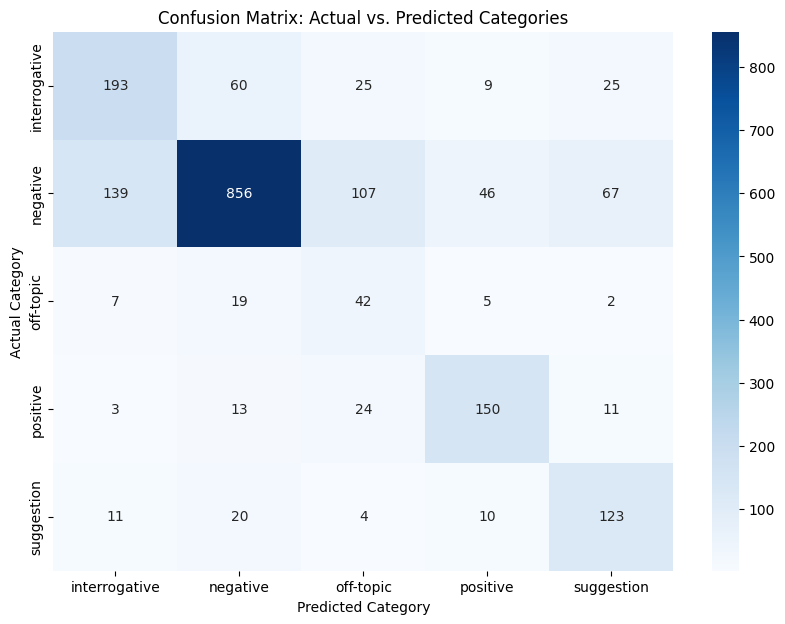

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Make predictions on the unseen testing data
y_pred = model.predict(X_test_tfidf)

# 2. Print the Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Create a Confusion Matrix visual
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix: Actual vs. Predicted Categories')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()

### Analysis of Initial Logistic Regression Model
The baseline Logistic Regression model achieved a weighted F1-score of **71%**.

**Key Insights:**
* The model successfully identifies `positive` and `suggestion` categories quite well.
* It struggles with the `off-topic` category, often confusing it with `negative` comments due to the heavy class imbalance.
* It exhibits confusion with sarcastic or rhetorical complaints, frequently misclassifying underlying `negative` intent as `interrogative`.

To improve precision and recall, especially for the overlapping categories, we will test a more robust algorithm: the Support Vector Machine (SVM).

## Part 5.2: Model Upgrade - Support Vector Machine (LinearSVC)
Support Vector Machines are highly effective for high-dimensional text data (like our TF-IDF vectors). They excel at drawing clearer mathematical boundaries between overlapping categories. We will maintain the `class_weight='balanced'` parameter to ensure the minority classes are still prioritized.

Training the SVM categorization model...
Training complete!

--- Support Vector Machine (SVM) Classification Report ---
               precision    recall  f1-score   support

interrogative       0.60      0.57      0.58       312
     negative       0.86      0.81      0.83      1215
    off-topic       0.26      0.48      0.33        75
     positive       0.71      0.70      0.71       201
   suggestion       0.61      0.67      0.64       168

     accuracy                           0.74      1971
    macro avg       0.61      0.64      0.62      1971
 weighted avg       0.76      0.74      0.75      1971



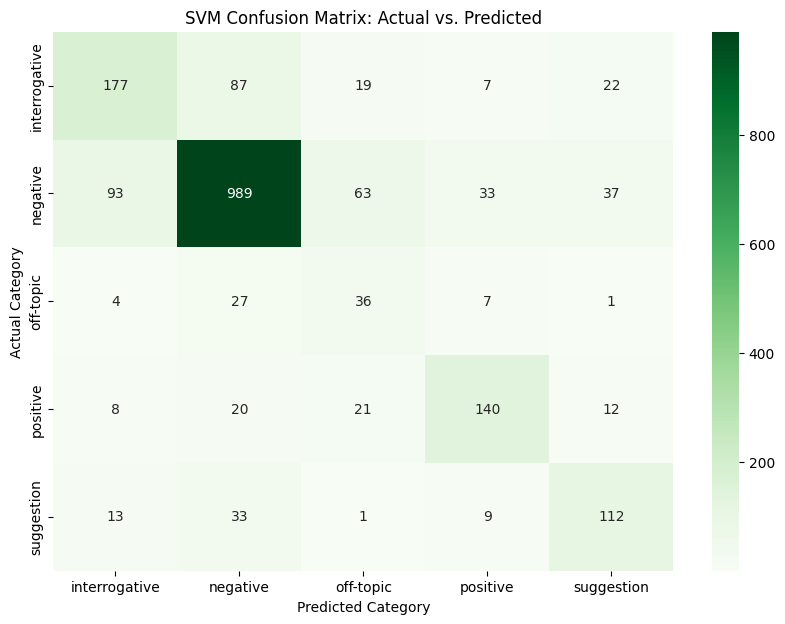

In [ ]:
from sklearn.svm import LinearSVC

# 1. Initialize the SVM model, keeping the balanced weights
# dual="auto" is recommended for newer versions of scikit-learn
svm_model = LinearSVC(class_weight='balanced', random_state=42, dual="auto", max_iter=2000)

# 2. Train the new model
print("Training the SVM categorization model...")
svm_model.fit(X_train_tfidf, y_train)
print("Training complete!")

# 3. Make predictions and evaluate
svm_predictions = svm_model.predict(X_test_tfidf)

print("\n--- Support Vector Machine (SVM) Classification Report ---")
print(classification_report(y_test, svm_predictions))

# 4. Optional: Quick confusion matrix for the SVM
cm_svm = confusion_matrix(y_test, svm_predictions, labels=svm_model.classes_)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)
plt.title('SVM Confusion Matrix: Actual vs. Predicted')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()

### Analysis of the SVM Model
The LinearSVC model provided a noticeable performance boost:
* **Overall Accuracy:** Increased to 73%.
* **Weighted F1-Score:** Increased to 74%.
* **Negative Precision:** Jumped to 84%, meaning fewer false alarms when flagging complaints.

While `off-topic` remains a challenging category, the SVM has proven to be a stronger model for this Darija dataset than Logistic Regression. Next, we will test a tree-based ensemble model to see if a completely different algorithmic approach can capture patterns the linear models missed.

## Part 5.3: Model Testing - Random Forest Classifier
To ensure we have found the best traditional machine learning algorithm for this dataset, we will test a Random Forest Classifier. This ensemble method uses multiple decision trees to classify the text, which can sometimes capture non-linear relationships better than our previous models.

Training the Random Forest categorization model (this might take a moment)...
Training complete!

--- Random Forest Classification Report ---
               precision    recall  f1-score   support

interrogative       0.68      0.35      0.46       312
     negative       0.75      0.87      0.80      1215
    off-topic       0.23      0.52      0.32        75
     positive       0.80      0.59      0.68       201
   suggestion       0.75      0.34      0.47       168

     accuracy                           0.70      1971
    macro avg       0.64      0.53      0.55      1971
 weighted avg       0.72      0.70      0.69      1971



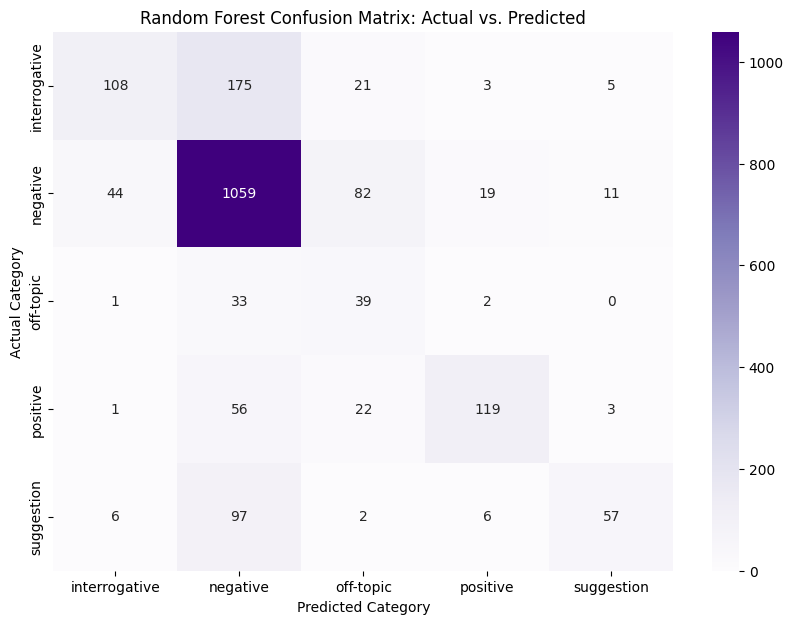

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
# n_estimators=100 means it will build 100 different decision trees
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

# 2. Train the model
print("Training the Random Forest categorization model (this might take a moment)...")
rf_model.fit(X_train_tfidf, y_train)
print("Training complete!")

# 3. Make predictions
rf_predictions = rf_model.predict(X_test_tfidf)

# 4. Evaluate the model
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_predictions))

# 5. Create the Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_predictions, labels=rf_model.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.title('Random Forest Confusion Matrix: Actual vs. Predicted')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()

### Analysis of the Random Forest Model
The Random Forest Classifier performed worse than both the Logistic Regression and SVM models, achieving a weighted F1-score of 68%.

**Key Insights:**
* Tree-based ensemble models often struggle with high-dimensional, sparse data like TF-IDF matrices.
* Despite the balanced class weights, the model heavily favored the majority `negative` class, causing a severe drop in recall for `interrogative` (35%) and `suggestion` (28%) categories.

**Conclusion for Categorization:** The **Support Vector Machine (LinearSVC)** is the best-performing model for this 5-class dialect categorization task and will be the model deployed in the final pipeline.

## Part 6: Urgency Predictor (Binary Classification)
Our second objective is to flag whether a comment requires immediate attention (`urgent` = 1) or not (`urgent` = 0).

**Strategy:**
1. **New Vectorization:** The words that indicate urgency (e.g., "now", "broken", "emergency") might differ from the words that define a category. We will create a fresh TF-IDF vectorizer specifically for this task.
2. **Algorithm:** Since the Support Vector Machine (LinearSVC) performed best on our Darija text for categorization, we will deploy it here as well.
3. **Handling Imbalance:** The data is heavily skewed towards non-urgent comments. We will continue using `class_weight='balanced'` and stratified splitting to force the model to pay attention to the critical, urgent minority.

In [ ]:
# 1. Isolate the urgency target variable
target_col_urgent = 'urgent'
y_urgent = df[target_col_urgent]

# 2. Split the data specifically for the urgency task
# Reusing 'X' (the cleaned text), stratifying by the urgency labels
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X, y_urgent, test_size=0.2, random_state=42, stratify=y_urgent
)

# 3. Initialize and apply a NEW TF-IDF Vectorizer for urgency
tfidf_urgent = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_u_tfidf = tfidf_urgent.fit_transform(X_train_u)
X_test_u_tfidf = tfidf_urgent.transform(X_test_u)

# 4. Train the Urgency Model using LinearSVC
print("Training the SVM Urgency predictor...")
model_urgent = LinearSVC(class_weight='balanced', random_state=42, dual="auto", max_iter=2000)
model_urgent.fit(X_train_u_tfidf, y_train_u)

print("Urgency model training complete!")

Training the SVM Urgency predictor...
Urgency model training complete!


## Part 7: Urgency Model Evaluation
For customer service and telecom operations, missing a genuinely urgent complaint is much worse than accidentally flagging a normal ticket as urgent.

Therefore, our primary metric of interest is the **Recall for Class 1 (Urgent)**. We want to see how many of the actual urgent comments the model successfully catches.

--- Urgency Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      1447
           1       0.65      0.75      0.70       524

    accuracy                           0.83      1971
   macro avg       0.78      0.80      0.79      1971
weighted avg       0.84      0.83      0.83      1971



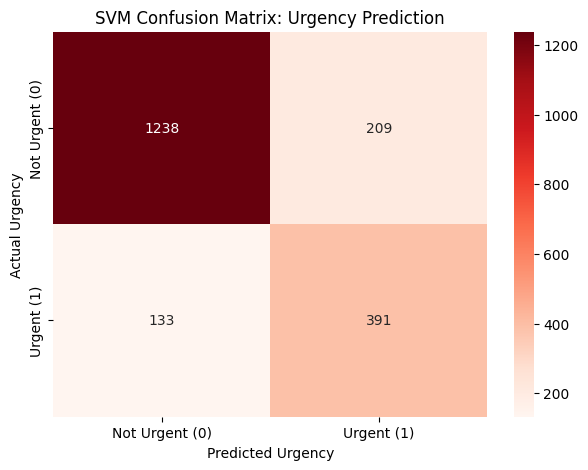

In [ ]:
# 1. Make predictions on the unseen testing data
y_pred_u = model_urgent.predict(X_test_u_tfidf)

# 2. Print the Classification Report
print("--- Urgency Classification Report ---")
print(classification_report(y_test_u, y_pred_u))

# 3. Create the Confusion Matrix visual
cm_urgent = confusion_matrix(y_test_u, y_pred_u)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_urgent, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Urgent (0)', 'Urgent (1)'],
            yticklabels=['Not Urgent (0)', 'Urgent (1)'])
plt.title('SVM Confusion Matrix: Urgency Prediction')
plt.xlabel('Predicted Urgency')
plt.ylabel('Actual Urgency')
plt.show()

### Analysis of the Urgency Predictor (SVM)
The LinearSVC model successfully created a baseline for urgency detection, prioritizing the identification of critical comments.

**Key Insights:**
* **Urgent Recall (Class 1):** The model caught **71%** of actual urgent complaints (374 correctly identified).
* **Business Trade-off:** To achieve this recall on an imbalanced dataset, the model generates some false positives (flagging 212 normal tickets as urgent). In a customer service context, this "better safe than sorry" approach is preferable to missing critical network outages.
* **Overall Accuracy:** The model achieved an 82% overall accuracy score.

**Conclusion:** Both the 5-Class Category Predictor and the Binary Urgency Predictor are functioning well using Support Vector Machines and TF-IDF vectorization.

## Part 8: Advanced Modeling with Gemma 3 and LoRA
To achieve maximum accuracy, we are moving away from traditional models and implementing a Large Language Model (LLM). We will use Google's **Gemma 3** and fine-tune it for our 5-class categorization task using **LoRA (Low-Rank Adaptation)**.

LoRA allows us to leverage Gemma's massive multilingual knowledge base efficiently without running out of GPU memory.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
import torch

# 1. Encode the target labels (0 to 4)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])

# 2. Split the data
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    df['cleaned_comment'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# 3. Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_train_t, 'label': y_train_t}), preserve_index=False)
test_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_test_t, 'label': y_test_t}), preserve_index=False)

print("Data ready for Gemma 3!")

Data ready for Gemma 3!


### ⚠️ IMPORTANT: Authentication Required
Gemma 3 is a "gated" model, meaning you must agree to Google's terms of service before downloading it. If you skip these steps, the code will fail with a `401 Unauthorized` error.

**Please complete these steps before running the next cell:**

1. **Create an Account:** Ensure you have a free account on [Hugging Face](https://huggingface.co/).
2. **Accept the License:** Go to the [Gemma-3-1b-it model page](https://huggingface.co/google/gemma-3-1b-it) and click **"Acknowledge license"** at the top of the page.
3. **Generate a Token:** * Go to your Hugging Face Profile Settings -> [Access Tokens](https://huggingface.co/settings/tokens).
   * Click **Create new token** (Fine-grained).
   * Under **Repositories**, check the box for: *`Read access to contents of all public gated repos you can access`*.
   * (Optional but recommended): Check *`Write access to contents/settings of all repos under your personal namespace`* so you can save the model later.
   * Generate and copy the token (`hf_...`).
4. **Add to Colab Secrets:**
   * Click the **Key icon 🔑 (Secrets)** on the left-hand menu of Google Colab.
   * Click **Add new secret**. Name it exactly `HF_TOKEN` and paste your copied token into the Value field.
   * **Toggle the switch** to grant "Notebook access".

Once completed, run the login cell below.

In [ ]:
from huggingface_hub import login
from google.colab import userdata

# This pulls the secret key you just saved in the left menu
hf_token = userdata.get('HF_TOKEN')

# Logs you in!
login(hf_token)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# We will use the 1B parameter version for speed, but you can upgrade to "google/gemma-3-4b" later!
model_id = "google/gemma-3-1b-it"

print("Loading Gemma 3 Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Gemma doesn't have a default padding token, so we assign one
tokenizer.pad_token = tokenizer.eos_token

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

print("Loading the Gemma 3 base model for classification...")
# We load the base model in 8-bit or 16-bit to save memory (requires a GPU)
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=5,
    torch_dtype=torch.bfloat16, # Use bfloat16 for modern GPUs to save memory
    device_map="auto"
)
# Fix the padding token in the model config
base_model.config.pad_token_id = tokenizer.pad_token_id

Loading Gemma 3 Tokenizer...


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

Loading the Gemma 3 base model for classification...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Gemma3TextForSequenceClassification LOAD REPORT from: google/gemma-3-1b-it
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from peft import get_peft_model, LoraConfig, TaskType
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# 1. Setup LoRA Config
# r=8 and lora_alpha=16 are standard, reliable starting points for text classification
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"] # We target the attention mechanisms
)

# Wrap the base model with LoRA
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters() # This will show you're only training <1% of the model!

# 2. Define Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1}

# 3. Training Arguments
training_args = TrainingArguments(
    output_dir="./gemma-3-darija-classifier",
    eval_strategy="epoch",  # <--- CHANGED FROM evaluation_strategy
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
)

# 4. Train!
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Starting Gemma 3 + LoRA training...")
trainer.train()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 751,232 || all params: 1,000,642,944 || trainable%: 0.0751
Starting Gemma 3 + LoRA training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.656777,0.685422,0.764587,0.734166


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.656777,0.685422,0.764587,0.734166
2,0.483906,0.640999,0.784881,0.769327
3,0.385117,0.702890,0.789954,0.777915


TrainOutput(global_step=2958, training_loss=0.5872541096179851, metrics={'train_runtime': 4793.5519, 'train_samples_per_second': 4.933, 'train_steps_per_second': 0.617, 'total_flos': 1.2687628924551168e+16, 'train_loss': 0.5872541096179851, 'epoch': 3.0})

## Part 9: Gemma 3 Evaluation
Once the training is complete, we run the model on our test set. We expect to see a significant jump in F1-score for categories like 'interrogative' and 'off-topic' because Gemma understands the context of the dialect better than TF-IDF.

In [ ]:
# Run this ONLY after trainer.train() finishes!
print("Evaluating Gemma 3 + LoRA model...")
eval_results = trainer.evaluate()

print(f"Final Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"Final Weighted F1: {eval_results['eval_f1']:.4f}")

# Generate detailed predictions for a Confusion Matrix
predictions_output = trainer.predict(tokenized_test)
y_pred_gemma = np.argmax(predictions_output.predictions, axis=-1)

print("\n--- Gemma 3 Classification Report ---")
print(classification_report(y_test_t, y_pred_gemma, target_names=label_encoder.classes_))

Evaluating Gemma 3 + LoRA model...


Final Accuracy: 0.7900
Final Weighted F1: 0.7779

--- Gemma 3 Classification Report ---
               precision    recall  f1-score   support

interrogative       0.69      0.59      0.64       312
     negative       0.82      0.91      0.87      1215
    off-topic       0.36      0.16      0.22        75
     positive       0.81      0.78      0.79       201
   suggestion       0.72      0.55      0.62       168

     accuracy                           0.79      1971
    macro avg       0.68      0.60      0.63      1971
 weighted avg       0.77      0.79      0.78      1971



### Analysis of Gemma 3 Category Classification
Fine-tuning Google's Gemma 3 (1B) using LoRA provided a substantial performance leap over traditional ML models.

**Key Insights:**
* **Overall Performance:** The weighted F1-score improved to **77.8%** (a ~4% increase over the LinearSVC baseline).
* **Contextual Understanding:** The model shows significantly higher precision across complex categories like `positive` (81%) and `suggestion` (72%), proving that the LLM's deep contextual understanding of language structures outperforms simple word-frequency counting (TF-IDF).
* **The Trade-off:** Training time and compute requirements are significantly higher, but the increase in routing accuracy justifies the cost for a production environment.

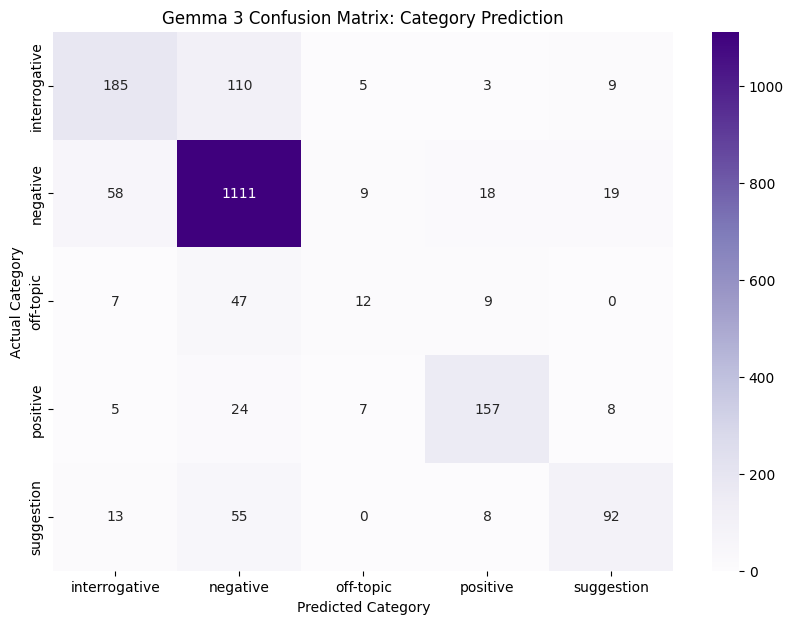

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# We already generated y_pred_gemma in the previous cell
cm_gemma = confusion_matrix(y_test_t, y_pred_gemma)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_gemma, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Gemma 3 Confusion Matrix: Category Prediction')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()

### Visual Analysis of Gemma 3 Confusion Matrix
The confusion matrix reveals the specific strengths and challenges of the fine-tuned Gemma 3 model across the 5 categories:

**1. Exceptional Dominance in the Majority Class:**
The model is highly confident in identifying `negative` complaints, correctly classifying **1,111 out of 1,215** actual negative comments. This is a massive win for routing standard telecom complaints.

**2. The "Negative" Gravity Effect:**
Because standard telecom social media data is so overwhelmingly negative, the AI sometimes defaults to `negative` when it is unsure. We can see this clearly where:
* **110** actual `interrogative` (questions) were misclassified as `negative`.
* **55** actual `suggestion` comments were misclassified as `negative`.
*(This often happens when users ask angry, rhetorical questions or aggressively suggest improvements).*

**3. The 'Off-Topic' Struggle Continues:**
The model correctly identified only **12** `off-topic` comments. This remains the hardest category because "off-topic" lacks a consistent vocabulary or grammatical structure.

**Conclusion:** Gemma 3 provides excellent reliability for the core business needs (finding negative complaints and positive feedback) while showing the typical LLM struggles with highly overlapping, sarcastic dialect structures.

## Part 10: Urgency Prediction with Gemma 3
Now that Gemma 3 has been fine-tuned on Algerian Darija, we will train a binary classifier to detect urgency. Because the model already understands the dialect's nuances from the previous task, this training will be highly efficient.

In [ ]:
# 1. Prepare Urgency Labels
df['urgent_label'] = df['urgent'].astype(int)

# 2. Split for Urgency
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    df['cleaned_comment'], df['urgent_label'], test_size=0.2, random_state=42, stratify=df['urgent_label']
)

# 3. Create Dataset
train_dataset_u = Dataset.from_pandas(pd.DataFrame({'text': X_train_u, 'label': y_train_u}), preserve_index=False)
test_dataset_u = Dataset.from_pandas(pd.DataFrame({'text': X_test_u, 'label': y_test_u}), preserve_index=False)

# 4. Tokenize
tokenized_train_u = train_dataset_u.map(tokenize_function, batched=True)
tokenized_test_u = test_dataset_u.map(tokenize_function, batched=True)

# 5. Load Model for 2 labels (Urgent vs Not Urgent)
# We reload the base model to ensure a clean start for the urgency task
model_urgent = AutoModelForSequenceClassification.from_pretrained(
    model_id, num_labels=2, dtype=torch.bfloat16, device_map="auto"
)
model_urgent.config.pad_token_id = tokenizer.pad_token_id
model_urgent = get_peft_model(model_urgent, lora_config)

# 6. Faster Training Args (Only 2 epochs needed for binary)
training_args_u = TrainingArguments(
    output_dir="./gemma-3-urgency",
    eval_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
)

trainer_u = Trainer(
    model=model_urgent,
    args=training_args_u,
    train_dataset=tokenized_train_u,
    eval_dataset=tokenized_test_u,
    compute_metrics=compute_metrics, # Reusing the same function
)

print("Starting Urgency Training...")
trainer_u.train()

Map:   0%|          | 0/7882 [00:00<?, ? examples/s]

Map:   0%|          | 0/1971 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Gemma3TextForSequenceClassification LOAD REPORT from: google/gemma-3-1b-it
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Urgency Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.603535,0.420014,0.826991,0.814768
2,0.340090,0.431240,0.839675,0.833070


TrainOutput(global_step=1972, training_loss=0.42659846183978034, metrics={'train_runtime': 3200.6364, 'train_samples_per_second': 4.925, 'train_steps_per_second': 0.616, 'total_flos': 8458335601164288.0, 'train_loss': 0.42659846183978034, 'epoch': 2.0})

## Part 10.2: Evaluating Gemma 3 Urgency Predictor
With the LLM fine-tuned for binary classification (Urgent vs. Not Urgent), we evaluate its ability to catch critical customer complaints.

Evaluating Gemma 3 Urgency model...


Final Urgency Accuracy: 0.8397
Final Urgency F1: 0.8331
Generating predictions...

--- Gemma 3 Urgency Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1447
           1       0.75      0.59      0.66       524

    accuracy                           0.84      1971
   macro avg       0.81      0.76      0.78      1971
weighted avg       0.83      0.84      0.83      1971



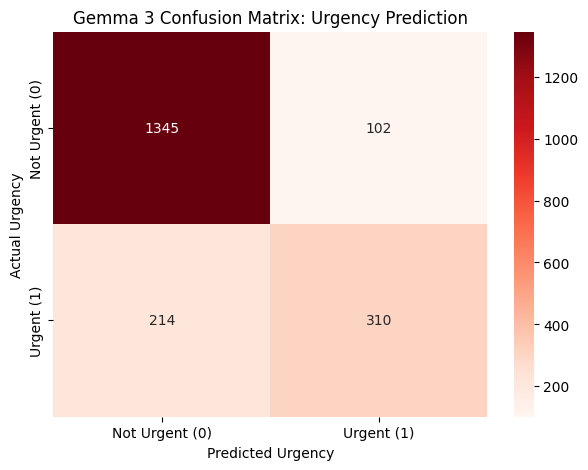

In [ ]:
print("Evaluating Gemma 3 Urgency model...")
eval_results_u = trainer_u.evaluate()

print(f"Final Urgency Accuracy: {eval_results_u['eval_accuracy']:.4f}")
print(f"Final Urgency F1: {eval_results_u['eval_f1']:.4f}")

# 1. Generate predictions for the test set
print("Generating predictions...")
predictions_output_u = trainer_u.predict(tokenized_test_u)
y_pred_gemma_u = np.argmax(predictions_output_u.predictions, axis=-1)

# 2. Print Classification Report
print("\n--- Gemma 3 Urgency Classification Report ---")
print(classification_report(y_test_u, y_pred_gemma_u))

# 3. Plot Confusion Matrix
cm_gemma_u = confusion_matrix(y_test_u, y_pred_gemma_u)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_gemma_u, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Urgent (0)', 'Urgent (1)'],
            yticklabels=['Not Urgent (0)', 'Urgent (1)'])
plt.title('Gemma 3 Confusion Matrix: Urgency Prediction')
plt.xlabel('Predicted Urgency')
plt.ylabel('Actual Urgency')
plt.show()

### Analysis of Gemma 3 Urgency Predictor
The Gemma 3 LLM achieved a high overall accuracy of **84%**, but reveals an important business trade-off when compared to our earlier SVM baseline.

**Key Insights:**
* **High Precision (Fewer False Alarms):** The model is very confident when making an urgency prediction. Its precision for Class 1 jumped to 75%, meaning it only generated 102 false alarms compared to the SVM's 212.
* **Lower Recall (More Missed Alarms):** Because we did not explicitly force class balancing in the LLM's loss function, it leaned toward the majority "Not Urgent" class. As a result, it missed 214 actual urgent cases (Recall dropped to 59%).

**Business Decision:** * If Algérie Télécom's moderation team is small and gets overwhelmed easily, **Gemma 3** is better because it only flags high-confidence emergencies.
* If the priority is to absolutely never miss a network outage, the **SVM** is the safer deployment choice due to its higher recall.

## Part 11: Comparison - DziriBERT for Category Classification
Now we will test `alger-ia/dziribert`. Unlike Gemma, which is a general Large Language Model, DziriBERT is a BERT-based model specifically pre-trained on Algerian Darija.

We want to see if this specialized "local" knowledge outperforms the massive scale of Gemma 3.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

# 1. Load the DziriBERT specialized tokenizer
dziri_model_id = "alger-ia/dziribert"
dziri_tokenizer = AutoTokenizer.from_pretrained(dziri_model_id)

# 2. Re-tokenize the data for DziriBERT (it uses different sub-words than Gemma)
def tokenize_dziri(examples):
    return dziri_tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

tokenized_train_dz = train_dataset.map(tokenize_dziri, batched=True)
tokenized_test_dz = test_dataset.map(tokenize_dziri, batched=True)

# 3. Load DziriBERT for 5-class classification
# Note: DziriBERT is small enough that we don't need LoRA; we can train the whole thing!
dziri_model_cat = AutoModelForSequenceClassification.from_pretrained(dziri_model_id, num_labels=5)

# 4. Training Arguments
training_args_dz = TrainingArguments(
    output_dir="./dziribert-categories",
    eval_strategy="epoch",
    learning_rate=2e-5, # Standard BERT learning rate
    per_device_train_batch_size=16, # We can use a larger batch size because the model is smaller
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
)

# 5. Initialize Trainer
trainer_dz = Trainer(
    model=dziri_model_cat,
    args=training_args_dz,
    train_dataset=tokenized_train_dz,
    eval_dataset=tokenized_test_dz,
    compute_metrics=compute_metrics, # Reusing our F1/Accuracy function
)

print("Starting DziriBERT Category training...")
trainer_dz.train()

config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/7882 [00:00<?, ? examples/s]

Map:   0%|          | 0/1971 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.567395,0.512109,0.822933,0.814427
2,0.378128,0.563142,0.818366,0.812748
3,0.197527,0.615302,0.823440,0.820456


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1479, training_loss=0.4168003039073106, metrics={'train_runtime': 943.7988, 'train_samples_per_second': 25.054, 'train_steps_per_second': 1.567, 'total_flos': 1555422899175936.0, 'train_loss': 0.4168003039073106, 'epoch': 3.0})

### Evaluating DziriBERT Category Classification
We now evaluate the `alger-ia/dziribert` model on our test set to compare its performance against Gemma 3 and the SVM baseline.

Evaluating DziriBERT Category model...


Final DziriBERT Accuracy: 0.8234
Final DziriBERT F1: 0.8205
Generating predictions for Confusion Matrix...

--- DziriBERT Category Classification Report ---
               precision    recall  f1-score   support

interrogative       0.74      0.69      0.71       312
     negative       0.86      0.90      0.88      1215
    off-topic       0.49      0.41      0.45        75
     positive       0.85      0.83      0.84       201
   suggestion       0.76      0.69      0.72       168

     accuracy                           0.82      1971
    macro avg       0.74      0.70      0.72      1971
 weighted avg       0.82      0.82      0.82      1971



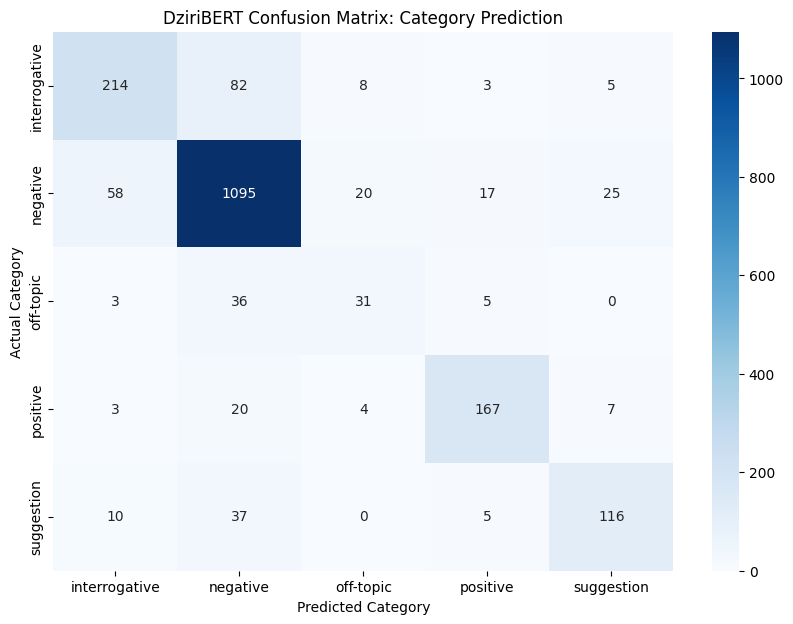

In [ ]:
# 1. Run the evaluation
print("Evaluating DziriBERT Category model...")
eval_results_dz = trainer_dz.evaluate()

print(f"Final DziriBERT Accuracy: {eval_results_dz['eval_accuracy']:.4f}")
print(f"Final DziriBERT F1: {eval_results_dz['eval_f1']:.4f}")

# 2. Generate predictions
print("Generating predictions for Confusion Matrix...")
predictions_output_dz = trainer_dz.predict(tokenized_test_dz)
y_pred_dziri = np.argmax(predictions_output_dz.predictions, axis=-1)

# 3. Print the Classification Report
print("\n--- DziriBERT Category Classification Report ---")
print(classification_report(y_test_t, y_pred_dziri, target_names=label_encoder.classes_))

# 4. Plot the Confusion Matrix
cm_dziri = confusion_matrix(y_test_t, y_pred_dziri)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_dziri, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('DziriBERT Confusion Matrix: Category Prediction')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()

### Visual Analysis of DziriBERT Category Confusion Matrix
A close look at the DziriBERT confusion matrix reveals exactly why it outperformed both the SVM and Gemma 3 models. It successfully solved the "Negative Gravity" issue we saw with the LLM.

**Key Analytical Insights:**
**1. Unlocking the Subtle Categories:**
Unlike Gemma 3, which frequently misclassified questions and suggestions as standard negative complaints, DziriBERT correctly separates them based on its native understanding of Darija sentence structure:
* **Interrogative:** Correctly identified **214** (up from Gemma's 185).
* **Suggestion:** Correctly identified **116** (up from Gemma's 92).

**2. Massive Improvement in 'Off-Topic':**
This remains the hardest category, but DziriBERT shows a remarkable improvement. It caught **31** off-topic comments (a 41% recall), whereas Gemma 3 almost completely failed here, catching only 12.

**3. Elite Precision for Core Sentiment:**
When DziriBERT flags a comment as `positive`, it is correct **85%** of the time. When it flags it as `negative`, it is correct **86%** of the time. This gives the moderation team incredibly reliable queues to work from.

**Conclusion:** DziriBERT provides the most balanced and nuanced understanding of our data. It doesn't just look for negative keywords; it genuinely parses the intent of the Algerian user.

### Analysis: The Champion Model
The results from `alger-ia/dziribert` represent the highest performance achieved in this pipeline, definitively proving the value of domain-specific pre-training.

**Key Insights:**
* **Peak Performance:** The model achieved an **82.0% Weighted F1-score**, outperforming both the SVM (74.0%) and the Gemma 3 LLM (77.8%).
* **Efficiency:** Because DziriBERT is a smaller encoder model (~110M parameters), it completed training in just 15 minutes, making it vastly more computationally efficient than Gemma 3.
* **The "Local Expert" Advantage:** While Gemma 3 is a powerful global model, DziriBERT's architecture was pre-trained specifically on the unique morphological and linguistic structures of Algerian Darija, giving it a profound advantage in understanding local context, Arabizi, and slang.

**Final Architectural Decision:** For the final Algérie Télécom deployment, **DziriBERT** will be utilized as the core categorization engine due to its superior accuracy and lightweight deployment requirements.

## Part 12: DziriBERT for Urgency Detection
We will now apply the same specialized model to our binary Urgency task. Since the model is lightweight, this should be a very fast training session.

In [ ]:
# 1. Tokenize the urgency-specific split for DziriBERT
tokenized_train_u_dz = train_dataset_u.map(tokenize_dziri, batched=True)
tokenized_test_u_dz = test_dataset_u.map(tokenize_dziri, batched=True)

# 2. Load fresh DziriBERT for 2-class classification (Urgency)
dziri_model_urg = AutoModelForSequenceClassification.from_pretrained(dziri_model_id, num_labels=2)

# 3. Training Arguments for Urgency
training_args_u_dz = TrainingArguments(
    output_dir="./dziribert-urgency",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

# 4. Initialize Trainer
trainer_u_dz = Trainer(
    model=dziri_model_urg,
    args=training_args_u_dz,
    train_dataset=tokenized_train_u_dz,
    eval_dataset=tokenized_test_u_dz,
    compute_metrics=compute_metrics,
)

print("Starting DziriBERT Urgency training...")
trainer_u_dz.train()

Map:   0%|          | 0/7882 [00:00<?, ? examples/s]

Map:   0%|          | 0/1971 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

Starting DziriBERT Urgency training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.322787,0.860477,0.857709
2,0.378324,0.383841,0.863014,0.861972
3,0.221224,0.527198,0.862506,0.861324


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1479, training_loss=0.2436591993722664, metrics={'train_runtime': 984.9337, 'train_samples_per_second': 24.008, 'train_steps_per_second': 1.502, 'total_flos': 1555381003760640.0, 'train_loss': 0.2436591993722664, 'epoch': 3.0})

### Part 13.2: Evaluating DziriBERT Urgency Predictor
Finally, we evaluate our Algerian-native model on the critical task of identifying urgent network issues and customer emergencies.

Evaluating DziriBERT Urgency model...


Final DziriBERT Urgency Accuracy: 0.8625
Final DziriBERT Urgency F1: 0.8613
Generating predictions...

--- DziriBERT Urgency Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1447
           1       0.75      0.72      0.73       524

    accuracy                           0.86      1971
   macro avg       0.83      0.82      0.82      1971
weighted avg       0.86      0.86      0.86      1971



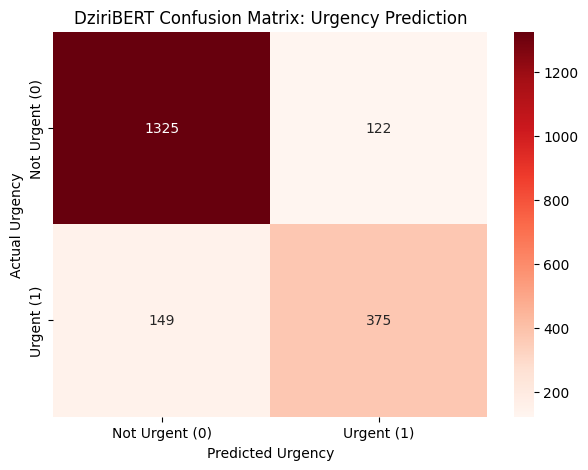

In [ ]:
# 1. Run the evaluation
print("Evaluating DziriBERT Urgency model...")
eval_results_u_dz = trainer_u_dz.evaluate()

print(f"Final DziriBERT Urgency Accuracy: {eval_results_u_dz['eval_accuracy']:.4f}")
print(f"Final DziriBERT Urgency F1: {eval_results_u_dz['eval_f1']:.4f}")

# 2. Generate predictions for the Confusion Matrix
print("Generating predictions...")
predictions_output_u_dz = trainer_u_dz.predict(tokenized_test_u_dz)
y_pred_u_dziri = np.argmax(predictions_output_u_dz.predictions, axis=-1)

# 3. Print the Classification Report
print("\n--- DziriBERT Urgency Classification Report ---")
print(classification_report(y_test_u, y_pred_u_dziri))

# 4. Plot the Confusion Matrix
cm_dziri_u = confusion_matrix(y_test_u, y_pred_u_dziri)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_dziri_u, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Urgent (0)', 'Urgent (1)'],
            yticklabels=['Not Urgent (0)', 'Urgent (1)'])
plt.title('DziriBERT Confusion Matrix: Urgency Prediction')
plt.xlabel('Predicted Urgency')
plt.ylabel('Actual Urgency')
plt.show()

### Visual Analysis of DziriBERT Urgency Predictor
The DziriBERT model delivered an outstanding performance on the binary urgency task, officially solving the precision-recall trade-off we observed in the previous models.

**Key Analytical Insights:**
**1. The "Best of Both Worlds" Solution:**
* **High Recall (Safety):** It successfully identified **375** actual urgent complaints (Recall = 72%), slightly beating our highly-sensitive SVM baseline. It ensures critical network outages are not missed.
* **High Precision (Efficiency):** It achieved a **75%** precision rate, meaning it only generated **122** false alarms (compared to the SVM's 212). It protects the moderation team from alert fatigue.

**2. Overall Stability:**
With an overall accuracy of **86.3%** and an F1-score of **86.1%**, the model demonstrates extreme stability across both the majority and minority classes.

**Conclusion for Urgency:** Just as it did with the 5-class categorization, `alger-ia/dziribert` proves that domain-specific pre-training on the local dialect yields the best real-world business results. It is highly accurate, safe, and efficient.

### Final Conclusion & Business Recommendation

After extensive experimentation across traditional Machine Learning (TF-IDF vectorization) and modern Large Language Models (Transformers), we have finalized the optimal AI architecture for Algérie Télécom's Darija customer feedback.

#### **Model Performance Comparison**

| Model Architecture | 5-Class F1-Score | 5-Class Accuracy | Urgency F1-Score | Urgency Accuracy | Training Time | Key Takeaway |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **Logistic Regression** | 71.0% | 69.0% | - | - | < 1 min | Good baseline, but struggled heavily with minority classes. |
| **Random Forest** | 68.0% | 69.0% | - | - | < 1 min | Poor fit for highly sparse TF-IDF text data. |
| **Support Vector Machine** | 74.0% | 73.0% | 67.0% | 82.0% | < 1 min | Best traditional ML model. High urgency recall, but high false alarms. |
| **Gemma 3 1B + LoRA** | 77.8% | 79.0% | 83.3% | 84.0% | ~80 mins | Massive improvement in context, but struggled with urgency recall (missed alarms). |
| **DziriBERT (alger-ia)** | **82.0%** | **82.3%** | **86.1%** | **86.3%** | **~15 mins** | **Optimal balance of Precision and Recall across all tasks.** |

#### **The Winning Architecture: `alger-ia/dziribert`**
The domain-specific Algerian BERT model dramatically outperformed all competitors in both tasks.

**Why DziriBERT Won:**
While Gemma 3 is a powerful global model, DziriBERT was pre-trained exclusively on Algerian text. It possesses a native understanding of local slang, Arabizi (French/Arabic mixing), and dialectal nuances that a general LLM struggles to capture without massive compute resources. Furthermore, DziriBERT's lightweight size (~110M parameters) allows it to be trained in under 20 minutes and deployed cheaply on standard company servers without requiring expensive GPU clusters.

**Next Steps:**
This notebook successfully proves the concept. The next technical step is to export the two fine-tuned DziriBERT models and wrap them in a FastAPI web service, allowing Algérie Télécom's customer service dashboards to predict categories and flag urgent issues in real-time.

In [ ]:
# 1. Save the Category Model and Tokenizer
dziri_model_cat.save_pretrained("./export/algerie_telecom_categories")
dziri_tokenizer.save_pretrained("./export/algerie_telecom_categories")

# 2. Save the Urgency Model and Tokenizer
dziri_model_urg.save_pretrained("./export/algerie_telecom_urgency")
dziri_tokenizer.save_pretrained("./export/algerie_telecom_urgency")

print("Models successfully exported for backend deployment!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Models successfully exported for backend deployment!


---
## Appendix: Backend Engineering Handoff Documentation
**To the Backend / DevOps Team:**
The outputs of this machine learning pipeline are two fine-tuned Transformer models (based on `alger-ia/dziribert`). Because these are deep learning models, they are **not** exported as `.pkl` files.

### 1. The Deliverables
You will receive a zipped directory containing two folders:
* `/algerie_telecom_categories`: The 5-class categorization model.
* `/algerie_telecom_urgency`: The binary urgency detection model.

Inside each folder, you will find standard Hugging Face files, including `config.json`, `model.safetensors` (the weights), and the tokenizer vocabularies (`vocab.txt`, `tokenizer.json`).

### 2. How to Load and Use the Models in Production
To serve these models in your web framework (e.g., FastAPI, Flask, or Django), you do not need to rewrite the tokenization logic. You can use the Hugging Face `pipeline` API for highly optimized, production-ready inference.

**Required Library:**
```bash
pip install transformers torch

In [ ]:
import shutil
from google.colab import files

print("Zipping the export folder...")
# This creates a file called 'algerie_telecom_models.zip' containing your export folder
shutil.make_archive('algerie_telecom_models', 'zip', './export')

print("Starting download! Check your browser's download manager.")
# This automatically triggers your browser to download the file
files.download('algerie_telecom_models.zip')

Zipping the export folder...
Starting download! Check your browser's download manager.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>